In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your car dataset using your exact path
df = pd.read_csv(r"C:\Users\DELL\Downloads\Oasis_Infobyte_Projects\car_data[1].csv")

# 1. Look at the column names and first few entries
print("--- FIRST 5 ROWS OF CAR DATA ---")
print(df.head())

# 2. Check the data types and look for missing values
print("\n--- DATASET DETAILS ---")
print(df.info())

--- FIRST 5 ROWS OF CAR DATA ---
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

--- DATASET DETAILS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Se

In [2]:
# 1. Convert text columns (Fuel_Type, Selling_type, Transmission) into numerical columns (0s and 1s)
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

# 2. Separate our features (X) from our target price (y)
# We drop 'Car_Name' because names are unique strings that don't help with regression math, 
# and we drop 'Selling_Price' because that's our target!
X = df_encoded.drop(['Car_Name', 'Selling_Price'], axis=1)
y = df_encoded['Selling_Price']

# 3. Import the splitting tool from Scikit-learn
from sklearn.model_selection import train_test_split

# 4. Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to make sure everything split evenly
print("Data splitting successful!")
print(f"Number of rows used for training: {X_train.shape[0]}")
print(f"Number of rows used for testing: {X_test.shape[0]}")

Data splitting successful!
Number of rows used for training: 240
Number of rows used for testing: 61


--- MODEL PERFORMANCE EVALUATION ---
R-squared Score (Accuracy): 84.89%
Mean Absolute Error: 1.22 Lakhs


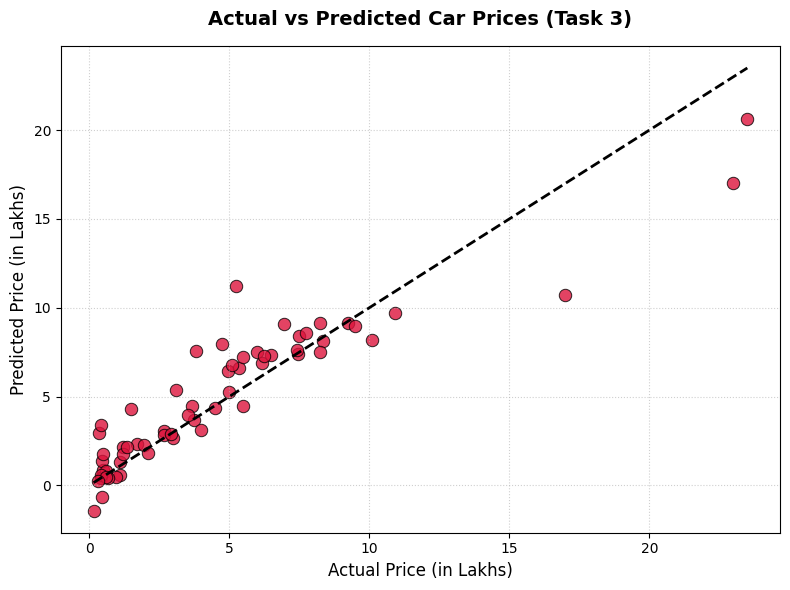

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Initialize and train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Generate price predictions using the test data
y_pred = model.predict(X_test)

# 3. Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- MODEL PERFORMANCE EVALUATION ---")
print(f"R-squared Score (Accuracy): {r2 * 100:.2f}%")
print(f"Mean Absolute Error: {mae:.2f} Lakhs")

# 4. Plot a professional comparison graph
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.8, color='crimson', edgecolor='black', s=80)

# Add a diagonal reference line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', lw=2, linestyle='--')

plt.title('Actual vs Predicted Car Prices (Task 3)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Price (in Lakhs)', fontsize=12)
plt.ylabel('Predicted Price (in Lakhs)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()